# Initial Setup for Multi-Class Classification
Loading necessary libraries and dataset.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random
import os
import joblib


In [17]:
# Load Dataset
df = pd.read_csv('data/amazon_sales_dataset.csv')
display(df.head())


,Date,Product_Category,Price,Discount_Percent,Final_Price,Ad_Spend_PPC,Stock_Level,Amazon_Buy_Box_Percentage,FBA_Status,Day_Of_Week,Is_Holiday,Weather,Season,Units_Sold,High_Demand
0,2023-01-01 00:00:00.000000,"Clothing, Shoes & Jewelry",28.91,0.5,14.45,20.75,595,0.90,FBA,6,0,Rain,1,315,1
1,2023-01-01 00:52:25.274527,Sports & Outdoors,440.65,0.0,440.65,63.30,891,0.12,FBM,6,0,Cloudy,1,51,0
2,2023-01-01 01:44:50.549054,Beauty & Personal Care,164.32,0.0,164.32,42.56,430,0.44,FBA,6,0,Cloudy,1,143,0
3,2023-01-01 02:37:15.823582,Sports & Outdoors,73.20,0.0,73.20,1.61,604,0.72,FBM,6,0,Cloudy,1,80,0
4,2023-01-01 03:29:41.098109,Sports & Outdoors,239.55,0.0,239.55,2.82,488,0.32,FBA,6,0,Clear,1,101,0


## 9. Extra: Multi-Class Classification with Softmax
**Business Objective:** Can we predict the *Product Category* of an item based solely on its financial metrics, ad spend, and external factors like weather?

Since there are multiple product categories, this is a **Multi-Class Classification** problem. We will build a Neural Network and use the **Softmax** activation function on the final output layer to generate probabilities for each of the distinct categories.

Training Multi-Class Softmax Model...
Training Complete!
Softmax Multi-Class Accuracy: 28.00%


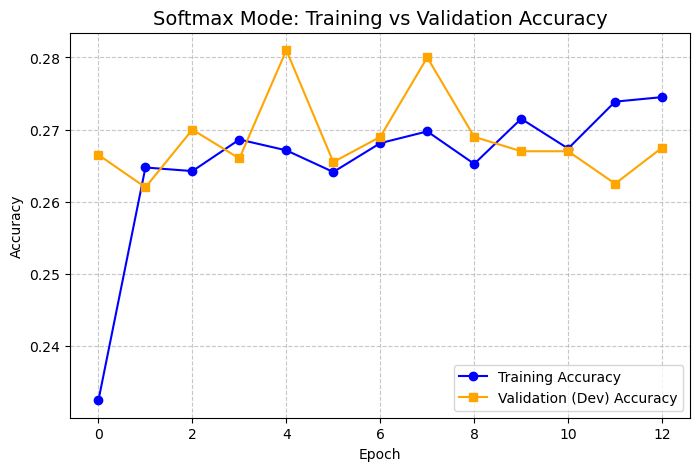

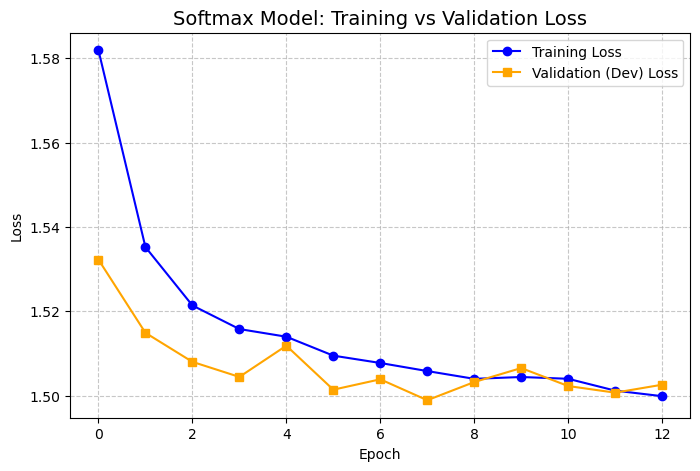

In [18]:

# 1. Data Preparation for Multi-Class
# Target: Product_Category
le = LabelEncoder()
y_multi = le.fit_transform(df['Product_Category'])
num_classes = len(le.classes_)

# Features: Everything except Date and Product_Category
X_multi = df.drop(columns=['Date', 'Product_Category'])

# We need a new preprocessor because categorical features list changed
cat_features_multi = ['FBA_Status', 'Weather']
num_features_multi = ['Price', 'Discount_Percent', 'Final_Price', 'Ad_Spend_PPC', 'Stock_Level', 
                      'Amazon_Buy_Box_Percentage', 'Day_Of_Week', 'Is_Holiday', 'Season', 'Units_Sold', 'High_Demand']

preprocessor_multi = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_multi),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features_multi)
    ])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

X_train_m_scaled = preprocessor_multi.fit_transform(X_train_m)
X_test_m_scaled = preprocessor_multi.transform(X_test_m)

# 2. Build Multi-Class Neural Network
model_multi = Sequential()
model_multi.add(Dense(64, activation='relu', input_shape=(X_train_m_scaled.shape[1],)))
model_multi.add(Dropout(0.2))
model_multi.add(Dense(64, activation='relu', input_shape=(X_train_m_scaled.shape[1],)))
model_multi.add(Dropout(0.2))
model_multi.add(Dense(32, activation='relu', input_shape=(X_train_m_scaled.shape[1],)))
model_multi.add(Dropout(0.2))
model_multi.add(Dense(16, activation='relu', input_shape=(X_train_m_scaled.shape[1],)))
model_multi.add(Dropout(0.2))
model_multi.add(Dense(32, activation='relu'))

# Softmax Activation for Multi-Class Output!
model_multi.add(Dense(num_classes, activation='softmax'))

# Compile using sparse_categorical_crossentropy because our targets are integers (Label Encoded)
model_multi.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train Model
print("Training Multi-Class Softmax Model...")
early_stop_multi = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_multi = model_multi.fit(X_train_m_scaled, y_train_m, validation_data=(X_test_m_scaled, y_test_m), epochs=50, batch_size=32, callbacks=[early_stop_multi], verbose=0)
print("Training Complete!")

# 4. Evaluate
loss, accuracy = model_multi.evaluate(X_test_m_scaled, y_test_m, verbose=0)
print(f"Softmax Multi-Class Accuracy: {accuracy*100:.2f}%")


# 5. Training vs Validation (Dev) Accuracy Comparison

plt.figure(figsize=(8, 5))
plt.plot(history_multi.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history_multi.history['val_accuracy'], label='Validation (Dev) Accuracy', color='orange', marker='s')
plt.title('Softmax Mode: Training vs Validation Accuracy', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotting the Loss as well for deeper comparison
plt.figure(figsize=(8, 5))
plt.plot(history_multi.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history_multi.history['val_loss'], label='Validation (Dev) Loss', color='orange', marker='s')
plt.title('Softmax Model: Training vs Validation Loss', fontsize=14)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 6. Detailed Evaluation & Examples

While overall accuracy gives us a high-level view, we need a deeper understanding of how the model performs across each individual product category. 

We will use:
*   **Classification Report:** Provides Precision, Recall, and F1-score for each specific `Product_Category`.
*   **Confusion Matrix:** A visual heatmap showing exactly where the model is getting confused (e.g., is it predicting "Beauty" when the true class is "Clothing"?).
*   **Prediction Examples:** We'll randomly sample a few items from the test set to see the model's actual predicted probabilities across all classes compared to the true label.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--- CLASSIFICATION REPORT ---
                           precision    recall  f1-score   support

   Beauty & Personal Care       0.00      0.00      0.00       389
Clothing, Shoes & Jewelry       0.17      0.06      0.09       400
              Electronics       0.79      0.36      0.49       380
           Home & Kitchen       0.25      0.27      0.26       415
        Sports & Outdoors       0.23      0.70      0.35       416

                 accuracy                           0.28      2000
                macro avg       0.29      0.28      0.24      2000
             weighted avg       0.29      0.28      0.24      2000


--- CONFUSION MATRIX ---


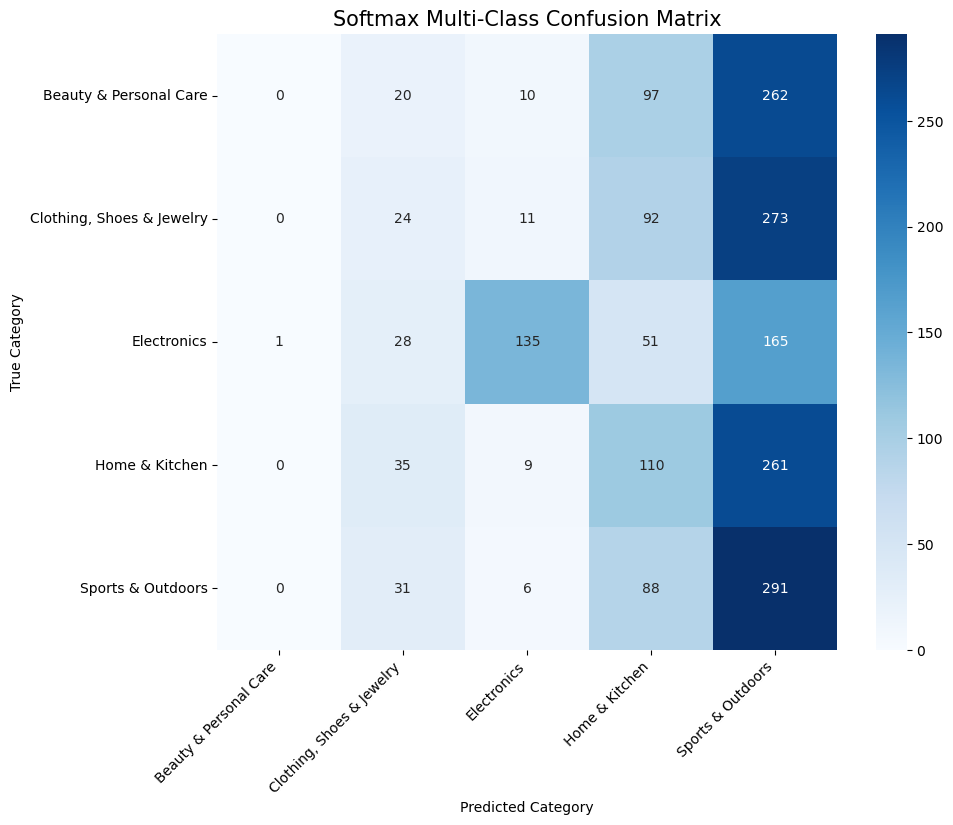


--- PREDICTION EXAMPLES ---
Example 1309:
  True Category      : Clothing, Shoes & Jewelry
  Predicted Category : Sports & Outdoors
  Softmax Probabilities:
    - Beauty & Personal Care: 21.20%
    - Clothing, Shoes & Jewelry: 21.33%
    - Electronics: 14.01%
    - Home & Kitchen: 21.66%
    - Sports & Outdoors: 21.80%
----------------------------------------
Example 228:
  True Category      : Clothing, Shoes & Jewelry
  Predicted Category : Sports & Outdoors
  Softmax Probabilities:
    - Beauty & Personal Care: 20.96%
    - Clothing, Shoes & Jewelry: 21.04%
    - Electronics: 14.70%
    - Home & Kitchen: 21.60%
    - Sports & Outdoors: 21.70%
----------------------------------------
Example 51:
  True Category      : Home & Kitchen
  Predicted Category : Sports & Outdoors
  Softmax Probabilities:
    - Beauty & Personal Care: 21.09%
    - Clothing, Shoes & Jewelry: 21.29%
    - Electronics: 14.23%
    - Home & Kitchen: 21.52%
    - Sports & Outdoors: 21.88%
------------------------

In [19]:

# Make predictions on the test set
# model_multi.predict outputs probabilities for each class due to the Softmax activation
y_pred_probs = model_multi.predict(X_test_m_scaled)

# Convert probabilities to actual class labels by picking the class with the highest probability
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get the original string names for the classes using our LabelEncoder
target_names = le.classes_

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test_m, y_pred_classes, target_names=target_names))

print("\n--- CONFUSION MATRIX ---")
# Plot confusion matrix
cm = confusion_matrix(y_test_m, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Softmax Multi-Class Confusion Matrix', fontsize=15)
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.show()

print("\n--- PREDICTION EXAMPLES ---")
# Let's look at 3 random examples from the test set
random.seed(42)
sample_indices = random.sample(range(len(y_test_m)), 3)

for i in sample_indices:
    true_label_idx = y_test_m[i]
    pred_label_idx = y_pred_classes[i]
    
    true_category = le.inverse_transform([true_label_idx])[0]
    pred_category = le.inverse_transform([pred_label_idx])[0]
    
    print(f"Example {i}:")
    print(f"  True Category      : {true_category}")
    print(f"  Predicted Category : {pred_category}")
    
    # Show the Softmax probability distribution for this example
    probs = y_pred_probs[i]
    print("  Softmax Probabilities:")
    for class_idx, prob in enumerate(probs):
        class_name = le.inverse_transform([class_idx])[0]
        print(f"    - {class_name}: {prob*100:.2f}%")
    print("-" * 40)


## 10. Deployment

Export the trained Softmax model and its preprocessing artifacts for use in the FastAPI REST API.


In [20]:
## 10. Deployment - Export Softmax Model Artifacts

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# 1. Save the trained Softmax Neural Network in native Keras format
print("Saving Softmax Neural Network...")
model_multi.save('models/softmax_model.keras')

# 2. Save the fitted preprocessor (ColumnTransformer with StandardScaler + OneHotEncoder)
print("Saving Softmax preprocessor...")
joblib.dump(preprocessor_multi, 'models/softmax_scaler.pkl')

# 3. Save the LabelEncoder class list so the API can decode integer predictions back to category names
print("Saving category labels...")
joblib.dump(list(le.classes_), 'models/category_labels.pkl')

print("\u2705 Softmax model artifacts saved to /models successfully!")
print(f"  - softmax_model.keras ({len(le.classes_)} output classes)")
print(f"  - softmax_scaler.pkl")
print(f"  - category_labels.pkl: {list(le.classes_)}")


Saving Softmax Neural Network...
Saving Softmax preprocessor...
Saving category labels...
✅ Softmax model artifacts saved to /models successfully!
  - softmax_model.keras (5 output classes)
  - softmax_scaler.pkl
  - category_labels.pkl: ['Beauty & Personal Care', 'Clothing, Shoes & Jewelry', 'Electronics', 'Home & Kitchen', 'Sports & Outdoors']
